<h1>1) Imports</h1>

In [25]:
!pip install tqdm
!pip install fastai

  Obtaining dependency information for fastai from https://files.pythonhosted.org/packages/b4/44/25472496c58a9c4aa43465ae8daffb4452ebbe61b43342fe0f8a53ed836b/fastai-2.7.13-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/67.6 kB ? eta -:--:--
     ------------------ --------------------- 30.7/67.6 kB ? eta -:--:--
     ---------------------------------------- 67.6/67.6 kB 1.2 MB/s eta 0:00:00
  Obtaining dependency information for spacy<4 from https://files.pythonhosted.org/packages/90/f0/0133b684e18932c7bf4075d94819746cee2c0329f2569db526b0fa1df1df/spacy-3.7.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for spacy-loggers<2.0.0,>=1.0.0 from https://files.pythonhosted.org/packages/33/78/d1a1a026ef3af911159398c939b1509d5c36fe524c7b644f34a5146c4e16/spacy_loggers-1.0.5-py3-none-any.whl.metadata
  Obtaining dependency information for murmurhash<1.1.0,>=0.28.0 from https://files.pythonhosted.org/packages/71/46/af01a20ec368bd9cb49a1d2df15e3e

In [89]:
import torch
import torchvision.datasets as dset 
import torchvision.transforms as transforms
import torch.utils.data as utils
import torch.nn.functional as F
import os
import torch.nn as nn
import torch.nn.init as init
from os import listdir
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam
import math
from tqdm import tqdm
from PIL import Image
from torchvision.utils import save_image
import shutil
import cv2
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset
from fastai.vision.all import *
from torch.optim.lr_scheduler import _LRScheduler


<h1>2) Préparation des données</h1>

On crée notre premier dataset contenant nos images originalles.

In [59]:
path_dset = 'imagesDisplay'
img_size = 64

#mean = torch.stack([img.mean(1).mean(1) for img, _ in train_dataset], dim=0).mean(0)
#std = torch.stack([img.std(1).std(1) for img, _ in train_dataset], dim=0).std(0)

#valeurs calculées à partir des formules commentées ci dessus
mean = [0.1896, 0.1856, 0.1790]
std = [0.0356, 0.0314, 0.0343]

train_dataset = dset.ImageFolder(path_dset, transform=transforms.Compose(
    [transforms.Resize(img_size), 
     transforms.CenterCrop(img_size),
     transforms.ToTensor(), #Converti en tenseur
     #transforms.Normalize(mean, std), #on normalise nos données grâce aux formules ci dessus. On peut alors avoir une normalisation customisé à notre jeu de données
     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) #normalisation plus générale, on encadre toutes nos valeurs entre 0 et 1.
     ]))


On crée une fonction permettant d'afficher les images de notre jeu de données. On utilise la librairie MatplotLib.

In [60]:
def show_img(dataset, num_sample=10, cols=5):
    plt.figure(figsize=(15, 15))
    for i, (img, label) in enumerate(dataset):
        if i == num_sample:
            break
        plt.subplot(num_sample // cols + 1, cols, i + 1)
        
        img = img.numpy().transpose((1, 2, 0))
        plt.imshow((img + 1) / 2)  #Dénormalisation des images dans le dataset
        plt.axis('off')
        plt.title(f'Class: {label}')

    plt.show()

d:\Anaconda\Lib\site-packages\PIL\Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


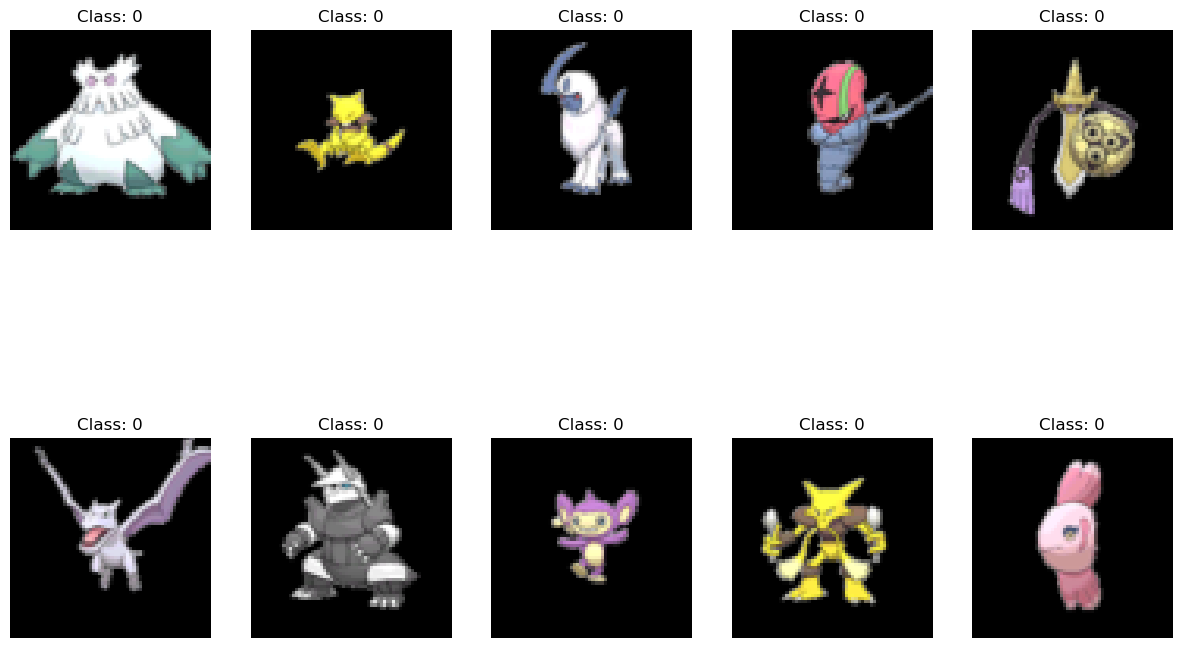

In [61]:
show_img(train_dataset)

On implémente le dataset dans un loader pour pouvoir charger les données dans le modèle.

In [62]:
batch_size = 128
workers = 0
origin_loader = utils.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=workers)
#num_images = len(train_loader.dataset) --> permet de définir la taille du batch (idéalement, il faut que num_image modulo batch soit égale à 0)

<h1>3) Quel est le principe d'un modèle de diffusion ?</h1>
<h2>a. Formules et concepts</h2>

Dans la passe avant (forward pass) l'idée est d'ajouter du bruit à l'image en input. On va utiliser un "Noise scheduler". Pour ajouter du bruit à l'image on utilse une loi de distribution Normale donnée par : 

$$ q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha_t}} {x}_0, (1 - \bar{\alpha_t})I) $$

Le premier paramètre de N représente notre output, le deuxième notre moyenne, et le troisième notre variance.

$$ \alpha_t = 1 - \beta(t) $$

$$ \bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s $$

$ {x}_t $ représente l'image au temps t (c'est à dire l'itération) et ${x}_0$ l'image originale fourni en input.

Le paramètre $\beta$ contôle la quantité de bruit que l'on ajoute dans l'image ${x}_t$.
La variance de la loi de distribution normale est défini par $((1 - \bar{\alpha_t})I)$ soit : 
$$ [1 - (\prod_{s=1}^{t} (1 - \beta_s))] * {I} $$

Pour une chaque pixels d'une image en entrée on va donc calculer $ q(x_t | x_0) $. On peut représenter la moyenne et la variance comme suit. La courbe bleu représente la loi de distribution normale avec un $\beta$ plus grand (c'est à dire qu'on ajoute plus de bruit).

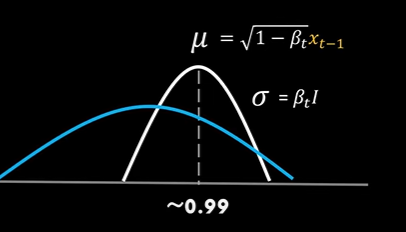

Plus simplement, la moyenne obtenue nous donne la nouvelle combinaison des valeurs RGB sur un pixel et la variance nous indique la pente de notre courbe. Plus la courbe est affaissée plus on ajoute de bruit.

L'objectif est d'avoir une valeur de $\beta$ telle que notre loi de distribution Normale soit centrée en 0 (moyenne égale à 0).

On définit $x(t)$, l'image bruitée à l'itération t par :
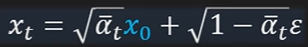.

$\epsilon$ représente la valeur du bruit. Il ne faut pas confondre cette variable avec $\beta$ qui représente, quant à elle, la quantité de bruit que l'on introduit dans l'image à l'itération t.

<h2>b. Appliquer du bruit à nos images</h2>

On va créer une fonction permettant d'appliquer du bruit à nos images originales. On va donc utiliser les images de notre origin_loader.
Dans un premier temps on crée une fonction capable de générer un tenseur contenant tous les betas.

In [63]:
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

Ensuite, on crée une fonction qui va nous permettre de récupérer la valeur d'un paramètre alpha en fonction de son itération t. La fonction suivante prend en compte la taille du lot d'image (notre batch) et on peut ainsi récupérer tous les alphas d'un même lot d'un coup.

In [64]:
def get_index_from_list(vals, t, x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

On définit un tenseur contenant toutes les valeurs des $\beta$ à chaque itération.

In [65]:
T=3000
betas = linear_beta_schedule(timesteps=T)

On défini ensuite des tenseurs contenant les valeurs des $\bar{\alpha}$ à chaque itération (alpha_cumprod pour produit cumulé) et toutes les valeurs nécessaires au calcul de la moyenne et de la variance comme la racine des $\bar{\alpha}$.

In [66]:
alphas = 1. - betas #calcul des alphas selon la formule vue précédemment.
alphas_cumprod = torch.cumprod(alphas, axis=0) #calcul des alpha_bar
sqrt_recip_alphas = torch.sqrt(1.0 / alphas) 
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod) #calcul de la racine des alpha_bar -> nécessaire pour calculer la moyenne de notre loi de distribution normale.
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod) #On calcul la racine de 1 - alpha_bar -> nécessaire pour le calcul de x(t).
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

On définit enfin notre fonction permettant l'ajout de bruit.

In [67]:
def forward_diffusion_sample(x_0, t, device="cpu"):
    #x_0 est l'image en input du modèle, c'est à dire l'image dans notre train_loader. Ce n'est pas une image bruitée.
    noise = torch.randn_like(x_0) #génère un tenseur de bruit aléatoire de même taille que le tenseur contenant l'image en input. 
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape) #permet d'extraire la valeur des alpha_bar pour l'itération t.
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    ) #permet d'extraire les valeurs de variance pour chaque itération.
    
    #On retourne la somme de la moyenne et de la variance -> on obtient notre nouvelle image bruitée.
    return [sqrt_alphas_cumprod_t.to(device) * x_0.to(device)] + [sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)], noise

Dans la fonction "forward_diffusion_sample" on retourne la somme de la moyenne et de la variance. Cela nous permet d'obtenir la nouvelle image bruitée.
En d'autres termes, la moyenne nous permet de pondérer l'image d'origine x_0 et la variance nous permet de pondérer le bruit noté noise.

Pondérer une image signifie ajuster l'influence de chaque pixel en multipliant chaque pixel par un coefficient spécifique ici $\beta$.

In [68]:
#fonction permettant d'afficher une image contenu dans un tenseur. 
def show_tensor_image(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), #convertit le format du tensor de CHW (canal, hauteur, largeur) à HWC (hauteur, largeur, canal).
        transforms.Lambda(lambda t: t * 255.), #Rescale les valeurs à [0, 255]
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)), #Convertit en tableau NumPy avec le type uint8
        transforms.ToPILImage(),
    ])
    
    #permet de vérifier si l'image est une liste. Si c'est le cas on ne prend que la première.
    if isinstance(image, list):
        image = image[0]

    #On vérifie si le tenseur possède une dimension de batch (auquel cas on a plusieurs images dans un même tenseur). Si c'est le cas on n'affiche que la première image.
    if len(image.shape) == 4:
        image = image[0, :, :, :]
    
    plt.imshow(reverse_transforms(image))

Dans la fonction show_tensor_image, on permute les dimensions du tenseur pour les rendre compatibles avec l'affichage matplotlib. En effet lorsque l'on crée un tenseur avec PyTorch, le tenseur est de format CHW (Nombre de canaux, hauteur, largeur). Avec Matplot le format est HWC (hauteur, largeur, canaux).
Le nombre de canaux indique notamment si les images sont en RGB (3) ou en grayscale.

Cette étape est donc cruciale pour pouvoir afficher correctement nos images.

In [69]:
def applyNoise(input_img):
    #on utilise matplotlib pour créer une figure sur laquelle seront affichés les images.
    plt.figure(figsize=(15,15))
    plt.axis('off')
    num_images = 10 #nombre d'images que l'on affiche sur notre figure
    stepsize = int(T/num_images) #écart entre deux images sur la figure.

    for idx in range(0, T, stepsize):
        t = torch.Tensor([idx]).type(torch.int64)
        plt.subplot(1, num_images+1, int(idx/stepsize) + 1)
        img, noise = forward_diffusion_sample(input_img, t)
        show_tensor_image(img)

    return img, noise

C:\Users\acail\AppData\Local\Temp\ipykernel_16656\1423371016.py:10: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, num_images+1, int(idx/stepsize) + 1)


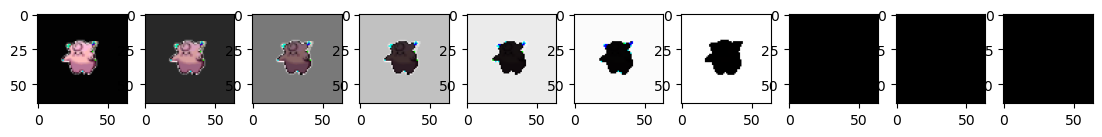

In [70]:
image = next(iter(origin_loader))[0] #crée un tableau contenant toutes les images de notre loader. Le [0] permet de récupérer le premier élément d'un tuple, c'ets à dire l'image.

img, _ = applyNoise(image)
img4Generation = img[0] #on va rentrer cette image bruitée dans le modèle pour générer une image.

<h1>4) Forward pass</h1>
<h2>a) Application du bruit</h2>

A présent que l'on sait que notre fonction de bruit fonctionne, on veut entrainer le modèle sur les images bruitées. On va donc copier les images dans un nouveau dossier 'noisyImg' et on va appliquer notre fonction 'applyNoise' à toutes les images de ce nouveau dossier. On pourra ensuite créer un dataset puis un dataloader comme précédemment.

In [ ]:
#-------------- On ne run cette cellule qu'une seule fois pour constituer notre dossier d'images bruitées --------------#

#Chemin du dossier source
dossier_source = './imagesDisplay/clean/'

#Chemin du dossier de destination
dossier_destination = './imagesTrain/noisy/'

#On s'assure que le dossier destination existe sinon on le crée
if not os.path.exists(dossier_destination):
    os.makedirs(dossier_destination)

#On parcours les images du dossier source
for fichier in os.listdir(dossier_source):
    #Chemin complet du fichier source
    chemin_source = os.path.join(dossier_source, fichier)

    #On vérifie sur le fichier est un fichier et non un sous dossier
    if os.path.isfile(chemin_source):
        #Chemin complet du fichier de destination
        chemin_destination = os.path.join(dossier_destination, fichier)

        #On copie le fichier vers le dossier destination
        shutil.copy(chemin_source, chemin_destination)

        #Lire l'image depuis le dossier de destination
        image = cv2.imread(chemin_destination)

        #Convertir l'image OpenCV en tensor PyTorch
        tensor_image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        #Appliquer du bruit à l'image
        noisy_image, noise = applyNoise(tensor_image)

        #Convertir l'image bruitée en format OpenCV et enregistrer
        noisy_image_cv2 = (noisy_image[0].permute(1, 2, 0) * 255.0).numpy().astype(np.uint8) #noisy_image[0] correspond à l'image bruitée. La fonction applyNoise renvoit une liste d'images comme affichée dans la cellule ci dessus.
        cv2.imwrite(chemin_destination, noisy_image_cv2)

print("Images copiées avec succès vers le nouveau dossier.")


<h2>b) Création d'un dataset et d'un dataloader contenant nos images bruitées </h2>

On crée notre dataset composé d'images bruitées.

In [43]:
pathNoise_dset = './imagesTrain'
img_size = 64

noisy_dataset = dset.ImageFolder(pathNoise_dset, transform=transforms.Compose(
    [transforms.Resize(img_size), 
     transforms.CenterCrop(img_size),
     transforms.ToTensor(), #Converti en tenseur
     #transforms.Normalize(mean, std), #on normalise nos données grâce aux formules ci dessus. On peut alors avoir une normalisation customisé à notre jeu de données
     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) #normalisation plus générale, on encadre toutes nos valeurs entre 0 et 1.
     ]))

On crée une classe Dataset pour pouvoir distinguer les images cleans des images noisy. En effet lors de l'entrainement on veut que le modèle fasse une prédiction sur une image bruitée. On va ensuite comparer cette prédiction avec l'image clean correspondante.
Si on utilise la fonction ImageFolder, par défaut on va récupérer une image et son label associé. A noter que l'on peut probablement utiliser ImageFolder en faisant ensuite une itération sur le loader comme : for (clean, labels),(noisy, labels) in loader :

In [71]:
class NoisyCleanDataset(Dataset):
    def __init__(self, clean_folder, noisy_folder, transform=None):
        self.clean_folder = clean_folder
        self.noisy_folder = noisy_folder
        self.transform = transform

        self.clean_images = os.listdir(clean_folder)
        self.noisy_images = os.listdir(noisy_folder)

    def __len__(self):
        return len(self.clean_images)

    def __getitem__(self, idx):
        clean_img_path = os.path.join(self.clean_folder, self.clean_images[idx])
        noisy_img_path = os.path.join(self.noisy_folder, self.noisy_images[idx])

        clean_image = Image.open(clean_img_path).convert('RGB')
        noisy_image = Image.open(noisy_img_path).convert('RGB')

        if self.transform:
            clean_image = self.transform(clean_image)
            noisy_image = self.transform(noisy_image)

        return clean_image, noisy_image


In [72]:
img_size = 64
transform=transforms.Compose(
    [transforms.Resize(img_size), 
     transforms.CenterCrop(img_size),
     transforms.ToTensor(), #Converti en tenseur
     #transforms.Normalize(mean, std), #on normalise nos données grâce aux formules ci dessus. On peut alors avoir une normalisation customisé à notre jeu de données
     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) #normalisation plus générale, on encadre toutes nos valeurs entre 0 et 1.
     ])


train_clean = './imagesTrain/clean'
train_noisy = './imagesTrain/noisy'
test_clean = './imagesTest/clean'
test_noisy = './imagesTest/noisy'

train_dataset = NoisyCleanDataset(train_clean, train_noisy, transform=transform)
test_dataset = NoisyCleanDataset(test_clean, test_noisy, transform=transform)

Puis notre data loader.

In [76]:
batch = 256
workers = 0
train_loader = utils.DataLoader(train_dataset, batch_size=batch, shuffle=True, num_workers=workers)
test_loader = utils.DataLoader(test_dataset, batch_size=batch, shuffle=True, num_workers=workers)

<h1>5) Back propagation</h1>
<h2>a) Réseau de neurones UNet</h2>

Création du réseau de neurones de type UNet.

In [77]:
class UNet(nn.Module):
    def __init__(self, input_channels, output_channels):
        super(UNet, self).__init__()
        #Up Sampling --> convolutions en cascade
        self.layer1 = self.encoderBlock(input_channels, 64)
        self.layer2 = self.encoderBlock(64, 128)
        self.layer3 = self.encoderBlock(128, 256)
        self.layer4 = self.encoderBlock(256, 512)
        self.layer5 = self.encoderBlock(512, 1024)

        #Goulot d'étranglement --> bas du U
        self.layer6 = self.bottleNeckBlock(1024)

        #Down Sampling --> Déconvolution
        self.layer7 = self.decoderBlock(1024, 512)
        self.layer8 = self.decoderBlock(512, 256)
        self.layer9 = self.decoderBlock(256, 128)
        self.layer10 = self.decoderBlock(128, 64)
        self.layer11 = self.decoderBlock(64, output_channels)
    
    def encoderBlock(self, input_channels, output_channels):
        return nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, stride=1), #3x3 convolution layer
            nn.ReLU(inplace=True), #activation function
            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU(inplace=True), #indique que la fonction d'activation doit être appliquée au tenseur en mémoire. Permet de modifier le tenseur directement sans en créer un autre.
            nn.MaxPool2d(kernel_size=2, stride=2) #la couche de MaxPool nous permet de réduire la dimension de notre image par 2.
        )
    
    #on crée un bloque pour le goulot d'étranglement contenant plus de couches de convolutions, et dont la dernière comporte une dilatation égale à 2.
    def bottleNeckBlock (self, input_channels):
        return nn.Sequential(
            nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, stride=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, stride=1), 
            nn.ReLU(inplace=True),
            nn.Conv2d(input_channels, input_channels, kernel_size=3, padding=1, stride=1), 
            nn.ReLU(inplace=True)
        )
    
    def decoderBlock(self, input_channels, output_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(input_channels, output_channels, kernel_size=2, stride=2),
            nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, stride=1),  # Add a convolutional layer
            nn.ReLU(inplace=True)
        )
    
    #méthode d'initialisation des poids du réseau. On utilise la méthode de He efficace dans le cadre d'applications de la fonction ReLU.
    @staticmethod
    def weights_init(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
            if m.bias is not None:
                init.constant_(m.bias.data, 0.0)
    
    def forward(self, x):
        #Up Sampling
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)

        #Goulot d'étranglement
        x = self.layer6(x)

        #Down Sampling
        x = self.layer7(x)
        x = self.layer8(x)
        x = self.layer9(x)
        x = self.layer10(x)
        x = self.layer11(x)
        x = torch.sigmoid(x) #on applique la fonction d'activation Sigmoid pour la dernière couche.
        x = F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=False) #resize pour que l'ouput soit égale à la taille de l'image en entrée dans le dataloader.
        #print("Output shape:", x.shape)
        
        return x

On peut schématiser un réseau de neurones UNet comme suit :

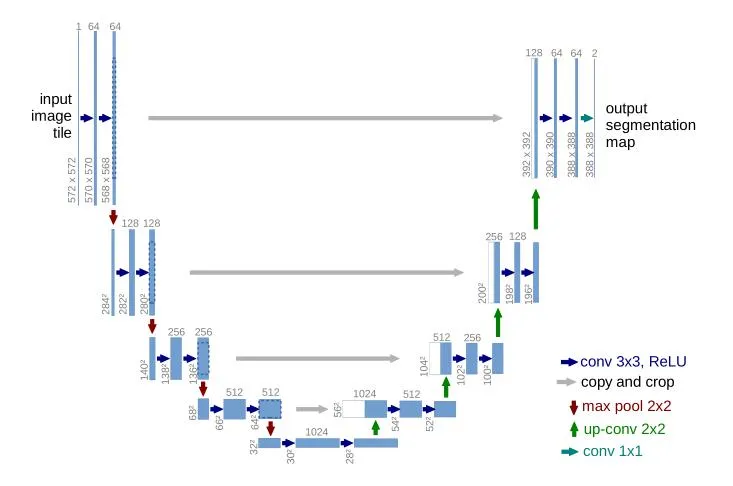

C'est enfaite une succession de bloques contenant des couches de convolutions et d'activations. Entre chaque bloque on peut appliquer des fonctions de MaxPool pour réduire la taille de l'image.

Un UNet se décompose donc en 3 parties : l'encodage, le goulot d'étranglement (ou bottleneck), et le décodage
L'encodage consiste en une succesion de bloques dis "encodeurs" composés de deux couches de convolutions entrecoupées de deux couches d'activations ReLU. 
Le goulot détranglement correspond au bas de notre "U". Pendant cette phase on ne veut surtout pas perdre la dimension de notre image, on va donc simplement appliquer une succession de couches convolutives dont les paramètres d'entrées sont égales aux paramètres de sorties.
Le décodage correspond en quelques sorte à la déconvolution.

Les valeurs de kernel et de stride sont généralement choisis par convention.

<h2>b) Entrainement</h2>

On crée une fonction pour l'entrainement de notre modèle. 
Le paramètre d'entrée critérion correspond à notre fonction de perte, optimizer est le paramètre nous permettant de mettre à jour les poids du réseau de neurones avec une fonction spécifique, ici SGD (stochastic gradient descent).

In [93]:
def training(model, epoch, optimizer, criterion, scheduler, device, test_loader):
    for i in tqdm(range(epoch), desc = "Progression"):
        model.train()
        num_batch = 1
        train_loss = 0
        valid_loss = 0
        for clean, noisy in train_loader:
            clean, noisy = clean.to(device), noisy.to(device)
            optimizer.zero_grad() #Réinitialisation des gradients
            
            pred_clean = model(noisy)

            #labels = labels.float()  #Converti les étiquettes en Float
            loss = criterion(pred_clean, clean) #on calcul l'écart entre la prédiction et le résultat réel donnée par le label
            loss.backward() #calcul des gradients

            optimizer.step() #on met à jour les poids du réseau de neurones avec la méthode des gradient descent.

            train_loss += loss.item()

            '''
            if (num_batch%100) == 0:
                print("Itération", i+1, ", perte pour le batch ", num_batch, ":", loss.item())
            num_batch += 1
            '''

        average_train_loss = train_loss / len(train_loader)
        print(f'Epoch {i+1}, Avg Train Loss : {average_train_loss}')

        
        if test_loader: #boucle de test --> on test le modèle sur un autre jeu de données qu'il n'a jamais rencontré.
            model.eval()
            loss=0.0
            with torch.no_grad(): #permet de ne pas calculer de nouveaux gradients.
                for img, labels in test_loader:
                        img, labels = img.to(device), labels.to(device)
                        pred = model(img)
                        labels = labels.float()
                        loss = criterion(pred, labels)
                        valid_loss += loss.item()

                average_valid_loss = valid_loss / len(test_loader)
                print(f'Epoch {i+1}, Avg Test Loss: {average_valid_loss}')

        scheduler.step() #fait évoluer le learning rate
 
    torch.save(model.state_dict(), 'trained_diffusion_model5.pth')
    print("Modèle entrainé avec succès !")
    return average_train_loss

On utilise la librairie FastAI pour utiliser la fonction lr_find qui nous permet d'optimiser la valeur initiale du learning rate.
On doit regrouper nos loaders dans un seul et même tenseur compréhensible par la librairie FastAI. On définit ensuite notre optimizer (l'optimizer choisit doit être le même que celui pris pour l'entrainement du modèle).
Enfin, on converti notre UNet en un learner compréhensible pour le framework.

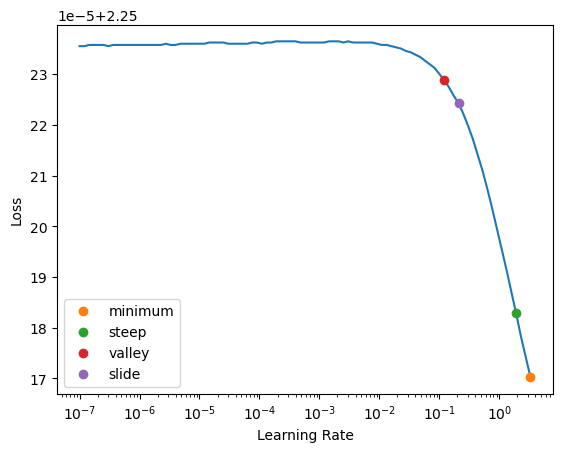

In [79]:
from fastai.data.core import DataLoaders

dls = DataLoaders(train_loader, test_loader)
opt_func = partial(OptimWrapper, opt=torch.optim.SGD) #on définit l'optimizer avec fastai
learn = Learner(dls, UNet(3,3), loss_func=nn.MSELoss(), opt_func=opt_func, metrics=accuracy)
lrs = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))

On obtient une courbe représentant l'évolution de la perte en fonction de la valeur du leanring rate. L'idée est de considérer une valeur de learning rate pour laquelle la perte décroit le plus rapidement possible et de façon linéaire. On choisi la valeur slide.

On définit nos variables globales pour l'entrainement.

In [94]:
rgb = True
lr = lrs.slide #learning rate
epoch = 10

#on prend un input égal à l'output car on a une tache de débruitage d'images --> chaque canal de sortie représente un canal d'information spécifique dans l'image d'origine.
if rgb:
    model = UNet(3, 3) 
else:
    model = UNet(1, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.MSELoss() #erreur des moindres carrés --> comparent chaque pixel de l'image générée avec le pixel correspondant de l'image propre.
scheduler = StepLR(optimizer, step_size=1, gamma=0.09) #permet d'ajuster la valeur du learning rate pendant l'entrainement du modèle. gamma contrôle la décroissance du learning rate --> paramètre multiplicatif. step_size indique toutes les combien itérations on ajuste le learning rate.
loss = training(model, epoch, optimizer, criterion, scheduler, device, test_loader=test_loader)

Progression:   0%|          | 0/10 [00:00<?, ?it/s]d:\Anaconda\Lib\site-packages\PIL\Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1, Avg Train Loss : 1.801954706509908


Progression:  10%|█         | 1/10 [00:21<03:14, 21.67s/it]

Epoch 1, Avg Test Loss: 2.250159740447998
Epoch 2, Avg Train Loss : 1.7139864762624104


Progression:  20%|██        | 2/10 [00:46<03:07, 23.46s/it]

...

Progression:  90%|█████████ | 9/10 [03:08<00:20, 20.43s/it]

Epoch 9, Avg Test Loss: 2.2501556873321533
Epoch 10, Avg Train Loss : 1.7252886692682903


Progression: 100%|██████████| 10/10 [03:28<00:00, 20.85s/it]

Epoch 10, Avg Test Loss: 2.2501556873321533


Modèle entrainé avec succès !


On charge le modèle entrainé, on le passe en mode évaluation (permet d'éviter le calcul de gradients) et on lui passe une image bruitée en entrée.

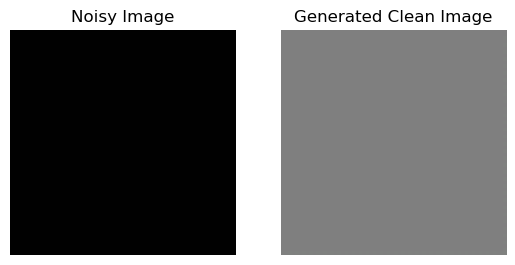

In [96]:
model = UNet(3,3)
model.load_state_dict(torch.load('trained_diffusion_model5.pth', map_location=device))
model.eval()

# Transformer l'image bruitée en tenseur
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

noisy_image_path = './imagesTrain/noisy/gogoat.png'
noisy_image = Image.open(noisy_image_path).convert('RGB')
noisy_image_tensor = transform(noisy_image).unsqueeze(0)  # Ajouter une dimension de batch

# Générer une image propre à partir de l'image bruitée
with torch.no_grad():
    clean_image_tensor = model(noisy_image_tensor)

# Convertir les tenseurs en images PIL pour l'affichage
noisy_image_pil = transforms.ToPILImage()(noisy_image_tensor.squeeze(0))
clean_image_pil = transforms.ToPILImage()(clean_image_tensor.squeeze(0))

# Afficher les images
plt.subplot(1, 2, 1)
plt.imshow(noisy_image_pil)
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(clean_image_pil)
plt.title('Generated Clean Image')
plt.axis('off')

plt.show()